# Klasyfikacja zmian skórnych przy użyciu MLP w PyTorch

**Imię i nazwisko:** Igor Józefowicz  
**Nr albumu:** 193257  
**Grupa:** UM1  
**Przedmiot:** Uczenie maszynowe  
**Data:** 11.06.2026 r.

Zadanie: klasyfikacja obrazów zmian skórnych do trzech kategorii: melanocytic nevi, melanoma oraz others.

## Założenia

Rozwiązanie korzysta z danych ISIC 2018 / HAM10000 i referencji `Skin Lesion Analysis Toward Melanoma Detection 2018` (`arXiv:1902.03368v2`).

Notatki:

- implementacja w PyTorch,
- obraz wejściowy `96x96`,
- model wyłącznie typu MLP,
- trzy klasy końcowe: `Melanocytic nevi`, `Melanoma`, `Others`,
- główna metryka: `weighted F1`,
- augmentacja danych treningowych: flip, mały crop oraz lekkie zmiany jasności i kontrastu.

In [1]:
from pathlib import Path
import copy
import random
import time
import warnings

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
IMAGE_SIZE = 96
DATA_DIR = Path("data")
TRAIN_IMAGE_DIRS = [
    DATA_DIR / "HAM10000_images_part_1",
    DATA_DIR / "HAM10000_images_part_2",
]
TEST_IMAGE_DIR = DATA_DIR / "ISIC2018_Task3_Test_Images" / "ISIC2018_Task3_Test_Images"
TRAIN_METADATA_PATH = DATA_DIR / "HAM10000_metadata"
TEST_METADATA_PATH = DATA_DIR / "ISIC2018_Task3_Test_GroundTruth.csv"
CHECKPOINT_PATH = Path("skin_lesion_mlp_pytorch.pt")

CLASS_NAMES = ["Melanocytic nevi", "Melanoma", "Others"]
CLASS_TO_INDEX = {name: index for index, name in enumerate(CLASS_NAMES)}


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA runtime:", torch.version.cuda)
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
CUDA runtime: 12.8
Device: cuda
GPU: NVIDIA GeForce RTX 4060 Ti


## Wczytanie danych i wybór klas

Oryginalne etykiety `dx` są mapowane do trzech klas:

- `nv` -> `Melanocytic nevi`,
- `mel` -> `Melanoma`,
- pozostałe klasy -> `Others`.

In [2]:
def map_dx_to_three_classes(dx):
    dx = str(dx).lower()
    if dx == "nv":
        return "Melanocytic nevi"
    if dx == "mel":
        return "Melanoma"
    return "Others"


def build_image_map(image_dirs):
    image_map = {}
    for image_dir in image_dirs:
        for path in Path(image_dir).glob("*.jpg"):
            image_map[path.stem] = path
    return image_map


def prepare_frame(metadata, image_map, split_name):
    frame = metadata.copy()
    frame["class_name"] = frame["dx"].map(map_dx_to_three_classes)
    frame["label"] = frame["class_name"].map(CLASS_TO_INDEX).astype(int)

    missing = sorted(set(frame["image_id"]) - set(image_map))
    if missing:
        print(f"{split_name}: missing images compared with CSV: {len(missing)}")
        print("First missing items:", missing[:10])

    frame = frame[frame["image_id"].isin(image_map)].copy()
    frame["path"] = frame["image_id"].map(lambda image_id: str(image_map[image_id]))
    return frame.reset_index(drop=True)


train_metadata = pd.read_csv(TRAIN_METADATA_PATH)
test_metadata = pd.read_csv(TEST_METADATA_PATH)

train_image_map = build_image_map(TRAIN_IMAGE_DIRS)
test_image_map = build_image_map([TEST_IMAGE_DIR])

train_df = prepare_frame(train_metadata, train_image_map, "train")
test_df = prepare_frame(test_metadata, test_image_map, "test")

print("Number of training images:", len(train_df))
print("Number of test images:", len(test_df))

display(pd.DataFrame({
    "train": train_df["class_name"].value_counts().reindex(CLASS_NAMES),
    "test": test_df["class_name"].value_counts().reindex(CLASS_NAMES),
}))

test: missing images compared with CSV: 1
First missing items: ['ISIC_0035068']
Number of training images: 10015
Number of test images: 1511


,train,test
class_name,,
Melanocytic nevi,6705,908
Melanoma,1113,171
Others,2197,432


In [3]:
original_counts = pd.DataFrame({
    "train_original_dx": train_metadata["dx"].value_counts(),
    "test_original_dx": test_metadata["dx"].value_counts(),
}).fillna(0).astype(int)

display(original_counts)

,train_original_dx,test_original_dx
dx,,
akiec,327,43
bcc,514,93
bkl,1099,217
df,115,44
mel,1113,171
nv,6705,909
vasc,142,35


## Przykładowe obrazy

Przykłady obejmują po dwa obrazy z każdej klasy po mapowaniu etykiet.

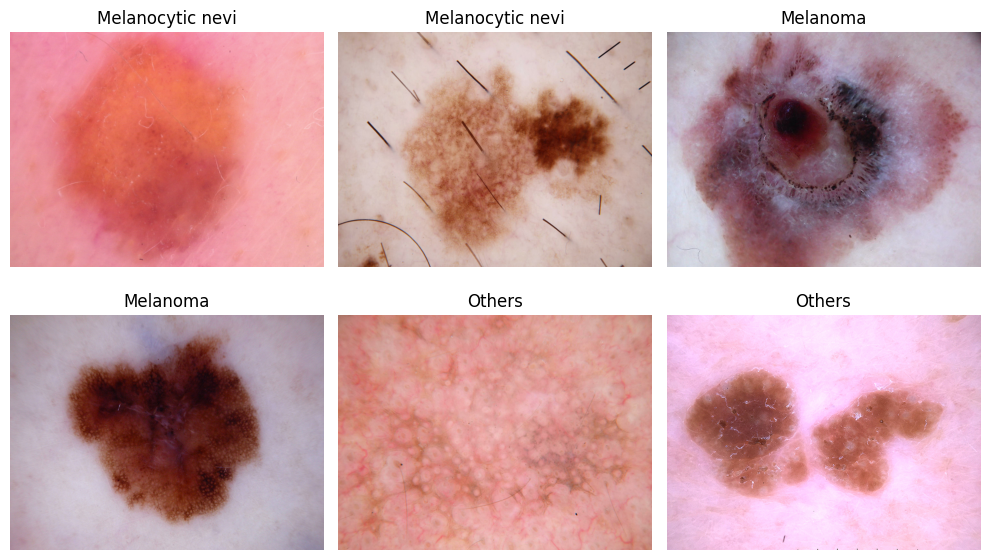

In [4]:
sample_df = train_df.groupby("class_name", group_keys=False).sample(2, random_state=SEED)

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
for ax, (_, row) in zip(axes.ravel(), sample_df.iterrows()):
    image = Image.open(row["path"]).convert("RGB")
    ax.imshow(image)
    ax.set_title(row["class_name"])
    ax.axis("off")
plt.tight_layout()
plt.show()

## Preprocessing

Obrazy są wczytywane jako RGB, skalowane do `96x96`, normalizowane i zamieniane na wektor wejściowy dla modelu. W zbiorze treningowym stosowana jest prosta augmentacja.

In [5]:
def read_resized_image(path, image_size=IMAGE_SIZE):
    with Image.open(path) as image:
        image = image.convert("RGB")
        image = image.resize((image_size, image_size), Image.Resampling.BILINEAR)
        return np.asarray(image, dtype=np.uint8)


def load_images_to_array(frame, image_size=IMAGE_SIZE):
    images = np.empty((len(frame), image_size, image_size, 3), dtype=np.uint8)
    start = time.time()
    for index, path in enumerate(frame["path"]):
        images[index] = read_resized_image(path, image_size)
        if (index + 1) % 2000 == 0:
            print(f"Loaded {index + 1}/{len(frame)} images")
    print(f"Image loading finished in {time.time() - start:.1f} s")
    return images


X_all = load_images_to_array(train_df)
y_all = train_df["label"].to_numpy(dtype=np.int64)

X_test = load_images_to_array(test_df)
y_test = test_df["label"].to_numpy(dtype=np.int64)

train_idx, val_idx = train_test_split(
    np.arange(len(train_df)),
    test_size=0.2,
    random_state=SEED,
    stratify=y_all,
)

print("X_all:", X_all.shape, X_all.dtype)
print("X_test:", X_test.shape, X_test.dtype)
print("train/validation/test:", len(train_idx), len(val_idx), len(y_test))

Loaded 2000/10015 images


Loaded 4000/10015 images


Loaded 6000/10015 images


Loaded 8000/10015 images


Loaded 10000/10015 images
Image loading finished in 59.7 s


Image loading finished in 8.9 s
X_all: (10015, 96, 96, 3) uint8
X_test: (1511, 96, 96, 3) uint8
train/validation/test: 8012 2003 1511


In [6]:
def compute_channel_stats(images, indices, chunks=20):
    indices = np.asarray(indices)
    sum_rgb = np.zeros(3, dtype=np.float64)
    sum_sq_rgb = np.zeros(3, dtype=np.float64)
    pixel_count = 0

    for chunk_indices in np.array_split(indices, chunks):
        if len(chunk_indices) == 0:
            continue
        pixels = images[chunk_indices].reshape(-1, 3).astype(np.float64) / 255.0
        sum_rgb += pixels.sum(axis=0)
        sum_sq_rgb += (pixels * pixels).sum(axis=0)
        pixel_count += pixels.shape[0]

    mean = sum_rgb / pixel_count
    variance = (sum_sq_rgb / pixel_count) - (mean * mean)
    std = np.sqrt(np.maximum(variance, 1e-8))
    return mean.astype(np.float32), std.astype(np.float32)


channel_mean, channel_std = compute_channel_stats(X_all, train_idx)
print("Mean RGB:", channel_mean)
print("Std RGB:", channel_std)

split_counts = pd.DataFrame({
    "train": pd.Series(y_all[train_idx]).value_counts().sort_index(),
    "validation": pd.Series(y_all[val_idx]).value_counts().sort_index(),
    "test": pd.Series(y_test).value_counts().sort_index(),
})
split_counts.index = CLASS_NAMES
display(split_counts)

Mean RGB: [0.76330477 0.5455673  0.5699035 ]
Std RGB: [0.13989165 0.15092848 0.16794313]


,train,validation,test
Melanocytic nevi,5364,1341,908
Melanoma,890,223,171
Others,1758,439,432


## Dataset i DataLoadery

`Dataset` korzysta z wcześniej wczytanych tablic obrazów. Augmentacja jest aktywna tylko dla zbioru treningowego.

In [7]:
def augment_image(image):
    if torch.rand(1).item() < 0.5:
        image = torch.flip(image, dims=[2])
    if torch.rand(1).item() < 0.25:
        image = torch.flip(image, dims=[1])

    if torch.rand(1).item() < 0.7:
        height, width = image.shape[1:]
        scale = float(torch.empty(1).uniform_(0.90, 1.00).item())
        crop_height = max(1, int(height * scale))
        crop_width = max(1, int(width * scale))
        top = int(torch.randint(0, height - crop_height + 1, (1,)).item())
        left = int(torch.randint(0, width - crop_width + 1, (1,)).item())
        image = image[:, top:top + crop_height, left:left + crop_width]
        image = F.interpolate(
            image.unsqueeze(0),
            size=(height, width),
            mode="bilinear",
            align_corners=False,
        ).squeeze(0)

    if torch.rand(1).item() < 0.7:
        brightness = float(torch.empty(1).uniform_(0.90, 1.10).item())
        contrast = float(torch.empty(1).uniform_(0.90, 1.10).item())
        channel_mean = image.mean(dim=(1, 2), keepdim=True)
        image = (image - channel_mean) * contrast + channel_mean
        image = image * brightness
        image = image.clamp(0.0, 1.0)

    return image


class SkinLesionArrayDataset(Dataset):
    def __init__(self, images, labels=None, indices=None, mean=None, std=None, augment=False):
        self.images = images
        self.labels = labels
        self.indices = np.arange(len(images)) if indices is None else np.asarray(indices)
        self.mean = torch.tensor(mean, dtype=torch.float32).view(3, 1, 1)
        self.std = torch.tensor(std, dtype=torch.float32).view(3, 1, 1)
        self.augment = augment

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, item):
        index = self.indices[item]
        image = torch.from_numpy(self.images[index]).permute(2, 0, 1).float() / 255.0
        if self.augment:
            image = augment_image(image)
        image = (image - self.mean) / self.std
        image = image.reshape(-1)

        if self.labels is None:
            return image
        return image, int(self.labels[index])


BATCH_SIZE = 256

train_dataset = SkinLesionArrayDataset(X_all, y_all, train_idx, channel_mean, channel_std, augment=True)
val_dataset = SkinLesionArrayDataset(X_all, y_all, val_idx, channel_mean, channel_std, augment=False)
test_dataset = SkinLesionArrayDataset(X_test, y_test, None, channel_mean, channel_std, augment=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

input_dim = IMAGE_SIZE * IMAGE_SIZE * 3
print("Batch size:", BATCH_SIZE)
print("Training augmentation:", train_dataset.augment)
print("Input dim:", input_dim)

Batch size: 256
Training augmentation: True
Input dim: 27648


## Projekt modelu

Trenowane są dwa pojedyncze warianty MLP, a do ewaluacji wybierany jest lepszy wynik walidacyjny. Nie jest stosowany ensemble.

Użyte techniki: `BatchNorm1d`, `Dropout`, `AdamW`, `weight_decay`, wagi klas w funkcji kosztu oraz prosta augmentacja treningowa.

In [8]:
def activation_layer(name):
    name = name.lower()
    if name == "relu":
        return nn.ReLU()
    if name == "elu":
        return nn.ELU()
    if name == "tanh":
        return nn.Tanh()
    raise ValueError(f"Unknown activation: {name}")


class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_layers, num_classes, activation="relu", dropout=0.3, batch_norm=True):
        super().__init__()
        layers = []
        previous_dim = input_dim

        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(previous_dim, hidden_dim))
            if batch_norm:
                layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(activation_layer(activation))
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            previous_dim = hidden_dim

        layers.append(nn.Linear(previous_dim, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


class_counts = np.bincount(y_all[train_idx], minlength=len(CLASS_NAMES))
class_weights = len(train_idx) / (len(CLASS_NAMES) * class_counts)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)

weights_df = pd.DataFrame({
    "class": CLASS_NAMES,
    "train_count": class_counts,
    "loss_weight": class_weights,
})
display(weights_df)

,class,train_count,loss_weight
0,Melanocytic nevi,5364,0.497887
1,Melanoma,890,3.000749
2,Others,1758,1.519151


In [9]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    total_items = 0

    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_items += batch_size

    return total_loss / total_items


def evaluate_model(model, loader, criterion=None):
    model.eval()
    total_loss = 0.0
    total_items = 0
    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            logits = model(images)

            if criterion is not None:
                loss = criterion(logits, labels)
                total_loss += loss.item() * labels.size(0)
                total_items += labels.size(0)

            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.append(probs.cpu().numpy())

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_prob = np.vstack(y_prob)

    metrics = {
        "loss": total_loss / total_items if criterion is not None else np.nan,
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
    }
    return metrics, y_true, y_pred, y_prob


def train_model(config):
    set_seed(SEED)
    model = MLPClassifier(
        input_dim=input_dim,
        hidden_layers=config["hidden_layers"],
        num_classes=len(CLASS_NAMES),
        activation=config["activation"],
        dropout=config["dropout"],
        batch_norm=config["batch_norm"],
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )

    best_state = None
    best_val_f1 = -1.0
    bad_epochs = 0
    history = []

    print(f"\nModel: {config['name']}")
    print("Parameter count:", count_parameters(model))

    for epoch in range(1, config["epochs"] + 1):
        start = time.time()
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
        val_metrics, _, _, _ = evaluate_model(model, val_loader, criterion)

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_f1_weighted": val_metrics["f1_weighted"],
            "val_f1_macro": val_metrics["f1_macro"],
            "seconds": time.time() - start,
        }
        history.append(row)

        print(
            f"epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={row['val_loss']:.4f} | "
            f"val_f1_weighted={row['val_f1_weighted']:.4f} | "
            f"time={row['seconds']:.1f}s"
        )

        if row["val_f1_weighted"] > best_val_f1 + 1e-4:
            best_val_f1 = row["val_f1_weighted"]
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= config["patience"]:
                print("Early stopping")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)
    best_row = history_df.loc[history_df["val_f1_weighted"].idxmax()].to_dict()
    return model, history_df, best_row

## Hiperparametry i trening

Dwa warianty różnią się aktywacją oraz rozmiarem warstw ukrytych.

In [10]:
EXPERIMENTS = [
    {
        "name": "mlp_relu_dropout",
        "hidden_layers": [256, 128],
        "activation": "relu",
        "dropout": 0.35,
        "batch_norm": True,
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "epochs": 12,
        "patience": 3,
    },
    {
        "name": "mlp_elu_dropout",
        "hidden_layers": [384, 192],
        "activation": "elu",
        "dropout": 0.35,
        "batch_norm": True,
        "lr": 8e-4,
        "weight_decay": 1e-4,
        "epochs": 12,
        "patience": 3,
    },
]

trained_models = {}
histories = {}
results = []

for config in EXPERIMENTS:
    model, history_df, best_row = train_model(config)
    trained_models[config["name"]] = model
    histories[config["name"]] = history_df
    results.append({
        "name": config["name"],
        "activation": config["activation"],
        "hidden_layers": str(config["hidden_layers"]),
        "dropout": config["dropout"],
        "best_epoch": int(best_row["epoch"]),
        "val_accuracy": best_row["val_accuracy"],
        "val_f1_weighted": best_row["val_f1_weighted"],
        "val_f1_macro": best_row["val_f1_macro"],
    })

results_df = pd.DataFrame(results).sort_values("val_f1_weighted", ascending=False)
display(results_df)


Model: mlp_relu_dropout
Parameter count: 7112195


epoch 01 | train_loss=0.9006 | val_loss=0.8227 | val_f1_weighted=0.6373 | time=7.2s


epoch 02 | train_loss=0.8343 | val_loss=0.7793 | val_f1_weighted=0.6491 | time=7.3s


epoch 03 | train_loss=0.8143 | val_loss=0.7601 | val_f1_weighted=0.6560 | time=6.8s


epoch 04 | train_loss=0.7970 | val_loss=0.7576 | val_f1_weighted=0.6716 | time=7.1s


...

epoch 09 | train_loss=0.7780 | val_loss=0.7549 | val_f1_weighted=0.6786 | time=6.5s


epoch 10 | train_loss=0.7721 | val_loss=0.7485 | val_f1_weighted=0.6961 | time=6.9s


epoch 11 | train_loss=0.7692 | val_loss=0.7407 | val_f1_weighted=0.6956 | time=7.2s


epoch 12 | train_loss=0.7714 | val_loss=0.7439 | val_f1_weighted=0.6730 | time=6.6s


,name,activation,hidden_layers,dropout,best_epoch,val_accuracy,val_f1_weighted,val_f1_macro
1,mlp_elu_dropout,elu,"[384, 192]",0.35,10,0.662506,0.696103,0.594679
0,mlp_relu_dropout,relu,"[256, 128]",0.35,5,0.659011,0.692102,0.598291


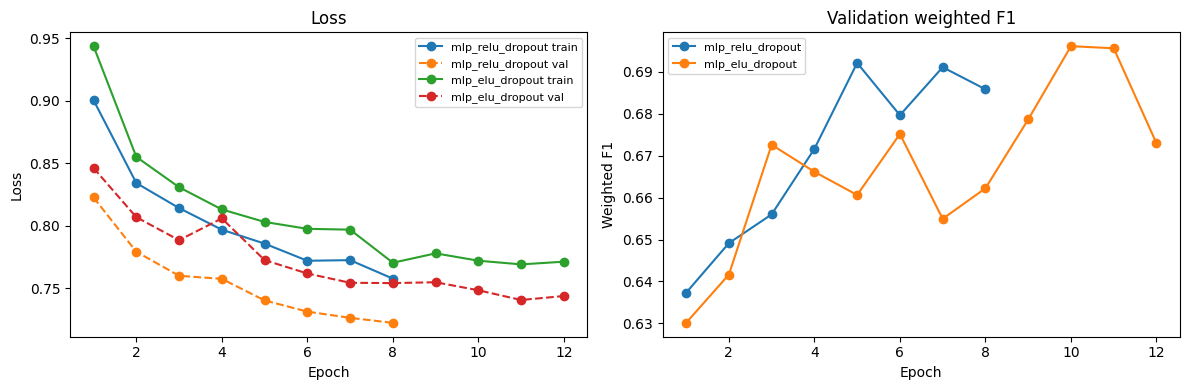

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, history_df in histories.items():
    axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label=f"{name} train")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", linestyle="--", label=f"{name} val")
    axes[1].plot(history_df["epoch"], history_df["val_f1_weighted"], marker="o", label=name)

axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=8)

axes[1].set_title("Validation weighted F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Weighted F1")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [12]:
best_name = results_df.iloc[0]["name"]
best_config = next(config for config in EXPERIMENTS if config["name"] == best_name)
best_model = trained_models[best_name]

checkpoint = {
    "model_state_dict": best_model.state_dict(),
    "config": best_config,
    "class_names": CLASS_NAMES,
    "image_size": IMAGE_SIZE,
    "channel_mean": channel_mean.tolist(),
    "channel_std": channel_std.tolist(),
}
torch.save(checkpoint, CHECKPOINT_PATH)

print("Selected model:", best_name)
print("Checkpoint saved:", CHECKPOINT_PATH)

Selected model: mlp_elu_dropout
Checkpoint saved: skin_lesion_mlp_pytorch.pt


## Ewaluacja na dostarczonym zbiorze testowym

Wyniki obejmują `weighted F1`, `macro F1`, accuracy, raport klasyfikacji i macierz pomyłek.

In [13]:
loaded_checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
loaded_config = loaded_checkpoint["config"]

final_model = MLPClassifier(
    input_dim=input_dim,
    hidden_layers=loaded_config["hidden_layers"],
    num_classes=len(CLASS_NAMES),
    activation=loaded_config["activation"],
    dropout=loaded_config["dropout"],
    batch_norm=loaded_config["batch_norm"],
).to(DEVICE)
final_model.load_state_dict(loaded_checkpoint["model_state_dict"])

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
test_metrics, test_true, test_pred, test_prob = evaluate_model(final_model, test_loader, criterion)

print("Test loss:", round(test_metrics["loss"], 4))
print("Test accuracy:", round(test_metrics["accuracy"], 4))
print("Test weighted F1:", round(test_metrics["f1_weighted"], 4))
print("Test macro F1:", round(test_metrics["f1_macro"], 4))
print()
print(classification_report(test_true, test_pred, target_names=CLASS_NAMES, digits=3))

Test loss: 0.7989
Test accuracy: 0.6135
Test weighted F1: 0.6478
Test macro F1: 0.5668

                  precision    recall  f1-score   support

Melanocytic nevi      0.873     0.604     0.714       908
        Melanoma      0.248     0.690     0.365       171
          Others      0.640     0.604     0.621       432

        accuracy                          0.614      1511
       macro avg      0.587     0.633     0.567      1511
    weighted avg      0.735     0.614     0.648      1511



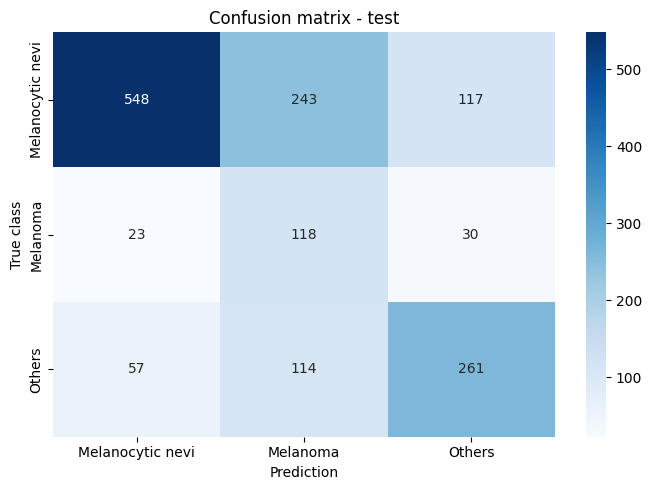

,Melanocytic nevi,Melanoma,Others
Melanocytic nevi,548,243,117
Melanoma,23,118,30
Others,57,114,261


In [14]:
cm = confusion_matrix(test_true, test_pred, labels=list(range(len(CLASS_NAMES))))
cm_df = pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prediction")
plt.ylabel("True class")
plt.title("Confusion matrix - test")
plt.tight_layout()
plt.show()

display(cm_df)

## Komórka do dodatkowego ukrytego testu

Prowadzący może podać folder z obrazami oraz opcjonalny CSV z metadanymi. Jeżeli CSV zawiera kolumnę `dx`, komórka policzy metryki; w przeciwnym razie zapisze predykcje do pliku CSV.

In [15]:
def load_checkpoint_model(checkpoint_path=CHECKPOINT_PATH, device=DEVICE):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    config = checkpoint["config"]
    model = MLPClassifier(
        input_dim=checkpoint["image_size"] * checkpoint["image_size"] * 3,
        hidden_layers=config["hidden_layers"],
        num_classes=len(checkpoint["class_names"]),
        activation=config["activation"],
        dropout=config["dropout"],
        batch_norm=config["batch_norm"],
    ).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model, checkpoint


def prepare_external_frame(image_dir, metadata_csv=None):
    image_dir = Path(image_dir)
    image_map = {path.stem: path for path in image_dir.rglob("*.jpg")}

    if metadata_csv is not None and Path(metadata_csv).exists():
        frame = pd.read_csv(metadata_csv).copy()
        if "image_id" not in frame.columns:
            raise ValueError("The metadata CSV must contain an image_id column.")
        missing = sorted(set(frame["image_id"]) - set(image_map))
        if missing:
            print(f"Missing images in hidden test folder: {len(missing)}")
            print("First missing items:", missing[:10])
        frame = frame[frame["image_id"].isin(image_map)].copy()
    else:
        frame = pd.DataFrame({"image_id": sorted(image_map)})

    frame["path"] = frame["image_id"].map(lambda image_id: str(image_map[image_id]))
    return frame.reset_index(drop=True)


def predict_probabilities(model, images, mean, std, batch_size=256):
    dataset = SkinLesionArrayDataset(images, labels=None, mean=mean, std=std)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )
    probabilities = []

    with torch.no_grad():
        for batch_images in loader:
            batch_images = batch_images.to(DEVICE, non_blocking=True)
            logits = model(batch_images)
            probabilities.append(torch.softmax(logits, dim=1).cpu().numpy())

    return np.vstack(probabilities)


def evaluate_hidden_dataset(
    image_dir,
    metadata_csv=None,
    checkpoint_path=CHECKPOINT_PATH,
    output_csv="hidden_test_predictions.csv",
):
    model, checkpoint = load_checkpoint_model(checkpoint_path)
    hidden_frame = prepare_external_frame(image_dir, metadata_csv)
    hidden_images = load_images_to_array(hidden_frame, image_size=checkpoint["image_size"])

    mean = np.asarray(checkpoint["channel_mean"], dtype=np.float32)
    std = np.asarray(checkpoint["channel_std"], dtype=np.float32)
    probabilities = predict_probabilities(model, hidden_images, mean, std)
    predicted_labels = probabilities.argmax(axis=1)

    output = pd.DataFrame({
        "image_id": hidden_frame["image_id"],
        "predicted_class": [checkpoint["class_names"][index] for index in predicted_labels],
    })

    for index, class_name in enumerate(checkpoint["class_names"]):
        safe_name = class_name.lower().replace(" ", "_")
        output[f"prob_{safe_name}"] = probabilities[:, index]

    output.to_csv(output_csv, index=False)
    print("Predictions saved:", output_csv)

    if "dx" in hidden_frame.columns:
        true_labels = hidden_frame["dx"].map(map_dx_to_three_classes).map(CLASS_TO_INDEX).to_numpy(dtype=np.int64)
        print("Hidden weighted F1:", f1_score(true_labels, predicted_labels, average="weighted"))
        print("Hidden macro F1:", f1_score(true_labels, predicted_labels, average="macro"))
        print(classification_report(true_labels, predicted_labels, target_names=checkpoint["class_names"], digits=3))

    return output


# The instructor can replace these paths:
HIDDEN_IMAGE_DIR = Path("hidden_test_images")
HIDDEN_METADATA_CSV = Path("hidden_test_metadata.csv")

if HIDDEN_IMAGE_DIR.exists():
    hidden_predictions = evaluate_hidden_dataset(
        image_dir=HIDDEN_IMAGE_DIR,
        metadata_csv=HIDDEN_METADATA_CSV if HIDDEN_METADATA_CSV.exists() else None,
    )
    display(hidden_predictions.head())
else:
    print("Hidden test cell is ready. Set HIDDEN_IMAGE_DIR and optionally HIDDEN_METADATA_CSV.")

Hidden test cell is ready. Set HIDDEN_IMAGE_DIR and optionally HIDDEN_METADATA_CSV.


## Krótkie podsumowanie

Model spełnia ograniczenia zadania: korzysta z podanych zbiorów train/test, używa architektury MLP i raportuje wymagane metryki. Wynik stanowi prosty baseline dla tego problemu.